In [1]:
import pandas as pd
from pybaseball import playerid_lookup
import numpy as np
import warnings
import os

# Suppress minor pybaseball warnings during data fetching
warnings.filterwarnings("ignore", category=FutureWarning)

def get_pitcher_statcast_data(player_name: str, opponent_team: str = None, batter_name: str = None) -> pd.DataFrame:
    """
    Loads raw Statcast pitch-by-pitch data from a local Parquet file 
    ('statcast_data_2025.parquet') and applies pitcher, opponent, and batter filters.
    
    NOTE: This assumes the data has already been preprocessed, including converting 
    pfx_x and pfx_z to inches, and adding boolean columns for 'swing', 'whiff', 
    'in_zone', 'out_zone', and 'chase'.

    Args:
        player_name (str): The name of the pitcher (e.g., 'Gerrit Cole').
        opponent_team (str, optional): Team code of the opponent (e.g., 'BOS'). Filters by opposing team.
        batter_name (str, optional): The name of the batter (e.g., 'Mike Trout'). Filters by batter.

    Returns:
        pd.DataFrame: A DataFrame of the filtered Statcast data.
    """
    FILE_PATH = './statcast_data_2025.parquet'

    if not os.path.exists(FILE_PATH):
        print(f"Error: Required file not found at {FILE_PATH}. Please ensure the data is preprocessed and saved.")
        return pd.DataFrame()

    print(f"--- 1. Loading data from {FILE_PATH} and applying filters ---")

    # Load the full preprocessed dataset (Movement is already in inches)
    try:
        data = pd.read_parquet(FILE_PATH)
        if data.empty:
            print(f"Warning: The file {FILE_PATH} is empty.")
            return pd.DataFrame()
        print(f"Full dataset loaded: {len(data)} pitches.")
    except Exception as e:
        print(f"Error reading Parquet file: {e}")
        return pd.DataFrame()

    filtered_data = data.copy()

    # 1. Filter by Pitcher ID
    try:
        lookup = playerid_lookup(player_name.split()[-1], player_name.split()[0])
        pitcher_id = lookup['key_mlbam'].iloc[0]
        # 'pitcher' column is the MLBAM ID of the pitcher
        filtered_data = filtered_data[filtered_data['pitcher'] == pitcher_id].copy()
        print(f"Filtered by Pitcher ({player_name}, ID: {pitcher_id}): {len(filtered_data)} pitches remaining.")
    except (IndexError, AttributeError):
        print(f"Error: Could not find MLBAM ID for pitcher: {player_name}. No data filtered for pitcher.")
        return pd.DataFrame()

    # 2. Filter by Opponent Team (Filter logic needs the pitcher's team ID)
    if opponent_team:
        # Infer the pitcher's team for each pitch based on fielding team
        # 'top' of the inning: Home team is fielding (pitcher's team)
        # 'bot' of the inning: Away team is fielding (pitcher's team)
        filtered_data.loc[:, 'inferred_pitcher_team'] = np.where(
            filtered_data['inning_topbot'] == 'top',
            filtered_data['home_team'],
            filtered_data['away_team']
        )
        
        # Get the pitcher's primary team ID (mode is safe for one pitcher)
        try:
            pitcher_team_id = filtered_data['inferred_pitcher_team'].mode().iloc[0]
        except IndexError:
            pitcher_team_id = None
        
        # Filter the pitches based on the opponent team
        if pitcher_team_id:
            opponent_team_upper = opponent_team.upper()
            filtered_data = filtered_data[
                # The pitcher's team is AWAY, and the opponent is the HOME team
                ((filtered_data['home_team'] == opponent_team_upper) & (filtered_data['away_team'] == pitcher_team_id)) |
                # The pitcher's team is HOME, and the opponent is the AWAY team
                ((filtered_data['away_team'] == opponent_team_upper) & (filtered_data['home_team'] == pitcher_team_id))
            ].copy()
            print(f"Filtered by Opponent ({opponent_team_upper}): {len(filtered_data)} pitches remaining.")
        else:
            print("Warning: Could not determine pitcher's team to apply opponent filter accurately.")
        
        # Clean up the temporary column
        filtered_data = filtered_data.drop(columns=['inferred_pitcher_team'], errors='ignore')


    # 3. Filter by Batter Name
    if batter_name:
        batter_lookup = playerid_lookup(batter_name.split()[-1], batter_name.split()[0])
        try:
            batter_id = batter_lookup['key_mlbam'].iloc[0]
            # 'batter' column is the MLBAM ID of the hitter
            filtered_data = filtered_data[filtered_data['batter'] == batter_id].copy()
            print(f"Filtered by Batter ({batter_name}, ID: {batter_id}): {len(filtered_data)} pitches remaining.")
        except IndexError:
            print(f"Warning: Could not find MLBAM ID for batter: {batter_name}. Batter filter skipped.")
            
    if filtered_data.empty:
        print("No data remaining after applying all filters.")

    return filtered_data.reset_index(drop=True)

def aggregate_pitch_metrics(data: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates key pitching metrics (counts, movement, discipline, batted ball) 
    grouped by pitch_name from raw Statcast data, using preprocessed columns.
    
    Args:
        data (pd.DataFrame): The raw, filtered Statcast DataFrame.

    Returns:
        pd.DataFrame: A table of aggregated pitch metrics.
    """
    if data.empty:
        return pd.DataFrame(columns=['Pitch', 'Pitches', 'xMov (Avg)', 'zMov (Avg)', 
                                     'LD%', 'GB%', 'FB%', 
                                     'O-Swing%', 'Z-Swing%', 'Contact%', 'Zone%', 'SwStr%'])

    print("--- 2. Aggregating Pitch Metrics ---")

    # --- Feature Engineering for Aggregation (Add compound columns) ---
    
    # FIX: Use .fillna(False) on launch_angle comparisons to prevent NaN values 
    # from being passed to np.select, which was causing the TypeError.
    
    is_hit_in_play = data['events'].notna()
    
    # Batted Ball Classification based on launch_angle (approximate standard)
    # Use .between() and .fillna(False) for robust boolean Series creation
    is_gb = is_hit_in_play & (data['launch_angle'] < 10).fillna(False)
    is_ld = is_hit_in_play & (data['launch_angle'].between(10, 25, inclusive='both')).fillna(False)
    is_fb = is_hit_in_play & (data['launch_angle'] > 25).fillna(False)
    
    data['bb_type_simple'] = np.select(
        [
            is_gb,
            is_ld,
            is_fb
        ],
        ['GB', 'LD', 'FB'],
        default=None
    )
    
    # Zone Swing Count (swing AND in_zone). We assume 'swing' and 'in_zone' are present.
    data['swing_in_zone'] = data['swing'] & data['in_zone']
    
    # --- Aggregation ---
    agg_df = data.groupby('pitch_name').agg(
        # Pitch Counts and Movement
        Pitches=('pitch_name', 'size'),
        xMov_Avg=('pfx_x', 'mean'), # Values are already in inches
        zMov_Avg=('pfx_z', 'mean'), # Values are already in inches
        
        # Plate Discipline Counts (using preprocessed columns)
        Total_Swings=('swing', 'sum'),
        Total_Whiffs=('whiff', 'sum'),
        Total_Pitches_Out_Zone=('out_zone', 'sum'),
        Total_Pitches_In_Zone=('in_zone', 'sum'),
        Total_Chase_Swings=('chase', 'sum'), # chase = swing & out_zone
        Total_Zone_Swings=('swing_in_zone', 'sum'), # swing_in_zone = swing & in_zone

        # Batted Ball Events (Only for balls put in play)
        Total_BB_Events=('bb_type_simple', lambda x: x.notna().sum()),
        GB_Count=('bb_type_simple', lambda x: (x == 'GB').sum()),
        FB_Count=('bb_type_simple', lambda x: (x == 'FB').sum()),
        LD_Count=('bb_type_simple', lambda x: (x == 'LD').sum())
    ).reset_index()

    # --- Rate Calculations ---

    # Movement (Already in inches, just round the average)
    agg_df['xMov (Avg)'] = (agg_df['xMov_Avg']).round(2)
    agg_df['zMov (Avg)'] = (agg_df['zMov_Avg']).round(2)

    # Batted Ball Rates (only calculated for pitches resulting in a Batted Ball Event)
    agg_df['LD%'] = np.where(agg_df['Total_BB_Events'] > 0, 
                             (agg_df['LD_Count'] / agg_df['Total_BB_Events'] * 100).round(1), 0.0)
    agg_df['GB%'] = np.where(agg_df['Total_BB_Events'] > 0, 
                             (agg_df['GB_Count'] / agg_df['Total_BB_Events'] * 100).round(1), 0.0)
    agg_df['FB%'] = np.where(agg_df['Total_BB_Events'] > 0, 
                             (agg_df['FB_Count'] / agg_df['Total_BB_Events'] * 100).round(1), 0.0)

    # Discipline Rates
    # O-Swing% (Chase%) = Total Chase Swings / Total Pitches Out of Zone
    agg_df['O-Swing%'] = np.where(agg_df['Total_Pitches_Out_Zone'] > 0,
                                 (agg_df['Total_Chase_Swings'] / agg_df['Total_Pitches_Out_Zone'] * 100).round(1), 0.0)
    
    # Z-Swing% = Total Zone Swings / Total Pitches In Zone
    agg_df['Z-Swing%'] = np.where(agg_df['Total_Pitches_In_Zone'] > 0,
                                 (agg_df['Total_Zone_Swings'] / agg_df['Total_Pitches_In_Zone'] * 100).round(1), 0.0)
                                 
    # Contact% = (Total Swings - Total Whiffs) / Total Swings
    agg_df['Contact%'] = np.where(agg_df['Total_Swings'] > 0, 
                                  ((agg_df['Total_Swings'] - agg_df['Total_Whiffs']) / agg_df['Total_Swings'] * 100).round(1), 0.0)
    
    # Zone% = Total Pitches In Zone / Total Pitches
    agg_df['Zone%'] = (agg_df['Total_Pitches_In_Zone'] / agg_df['Pitches'] * 100).round(1)
    
    # SwStr% (Swinging Strike %) = Total Whiffs / Total Pitches
    agg_df['SwStr%'] = (agg_df['Total_Whiffs'] / agg_df['Pitches'] * 100).round(1)


    # --- Final Formatting ---
    # Arrange columns in a comprehensive, readable order
    final_cols = ['pitch_name', 'Pitches', 'xMov (Avg)', 'zMov (Avg)', 
                  'LD%', 'GB%', 'FB%', 
                  'O-Swing%', 'Z-Swing%', 'Contact%', 'Zone%', 'SwStr%']
    
    # Rename columns and ensure only calculated columns are included
    final_df = agg_df[[col for col in final_cols if col in agg_df.columns]].rename(columns={'pitch_name': 'Pitch'})
    
    print("Aggregation complete.")
    return final_df.sort_values(by='Pitches', ascending=False)

In [2]:
# 1. Define Parameters
PITCHER_NAME = 'Hunter Brown'
OPPONENT_TEAM_FILTER = 'SEA' # Example: Filter for games against the Boston Red Sox
BATTER_NAME_FILTER = ''      # Example: No batter filter

print(f"--- RUNNING ANALYSIS FOR {PITCHER_NAME} ---")
print(f"Filters: Opponent='{OPPONENT_TEAM_FILTER if OPPONENT_TEAM_FILTER else 'None'}', Batter='{BATTER_NAME_FILTER if BATTER_NAME_FILTER else 'None'}'")
print("-" * 50)

# 2. Load and Filter Data from local Parquet file
filtered_data_df = get_pitcher_statcast_data(
    player_name=PITCHER_NAME,
    opponent_team=OPPONENT_TEAM_FILTER,
    batter_name=BATTER_NAME_FILTER
)

# 3. Aggregate Metrics
final_metrics_df = aggregate_pitch_metrics(filtered_data_df)

--- RUNNING ANALYSIS FOR Hunter Brown ---
Filters: Opponent='SEA', Batter='None'
--------------------------------------------------
--- 1. Loading data from ./statcast_data_2025.parquet and applying filters ---
Full dataset loaded: 701777 pitches.
Gathering player lookup table. This may take a moment.
Filtered by Pitcher (Hunter Brown, ID: 686613): 2872 pitches remaining.
Filtered by Opponent (SEA): 286 pitches remaining.
--- 2. Aggregating Pitch Metrics ---
Aggregation complete.


In [3]:
final_metrics_df.head()

,Pitch,Pitches,xMov (Avg),zMov (Avg),LD%,GB%,FB%,O-Swing%,Z-Swing%,Contact%,Zone%,SwStr%
0,4-Seam Fastball,111,-6.94,17.16,33.3,40.0,26.7,27.8,77.2,78.0,51.4,11.7
3,Knuckle Curve,56,5.36,-16.46,16.7,50.0,33.3,33.3,76.5,53.8,30.4,21.4
4,Sinker,56,-14.06,12.73,11.1,77.8,11.1,66.7,73.1,71.8,46.4,19.6
1,Changeup,35,-14.33,7.1,14.3,42.9,42.9,43.5,91.7,76.2,34.3,14.3
2,Cutter,21,2.81,6.85,0.0,33.3,66.7,35.7,57.1,66.7,33.3,14.3


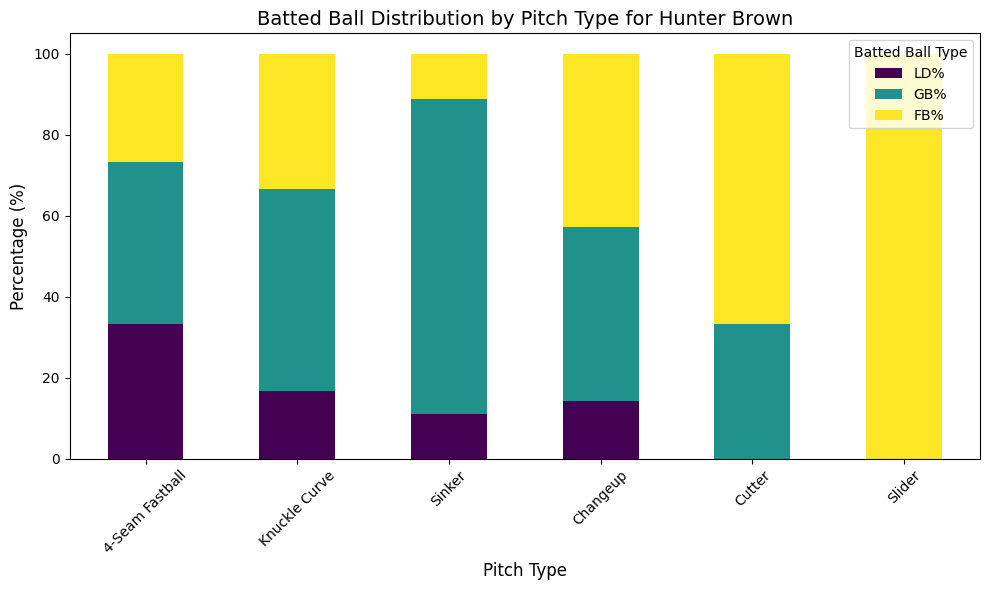

In [4]:
# Stacked Bar Chart
import matplotlib.pyplot as plt

def plot_batted_ball_distribution(agg_df: pd.DataFrame, pitcher_name: str):
    """
    Plots a stacked bar chart of batted ball distribution (LD%, GB%, FB%) by pitch type.

    Args:
        agg_df (pd.DataFrame): Aggregated pitch metrics DataFrame.
        pitcher_name (str): Name of the pitcher for the title.
    """
    if agg_df.empty:
        print("No data available to plot.")
        return

    # Extract relevant columns for plotting
    plot_data = agg_df[['Pitch', 'LD%', 'GB%', 'FB%']].set_index('Pitch')

    # Plotting
    ax = plot_data.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
    ax.set_title(f'Batted Ball Distribution by Pitch Type for {pitcher_name}', fontsize=14)
    ax.set_ylabel('Percentage (%)', fontsize=12)
    ax.set_xlabel('Pitch Type', fontsize=12)
    ax.legend(title='Batted Ball Type')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_batted_ball_distribution(final_metrics_df, PITCHER_NAME)

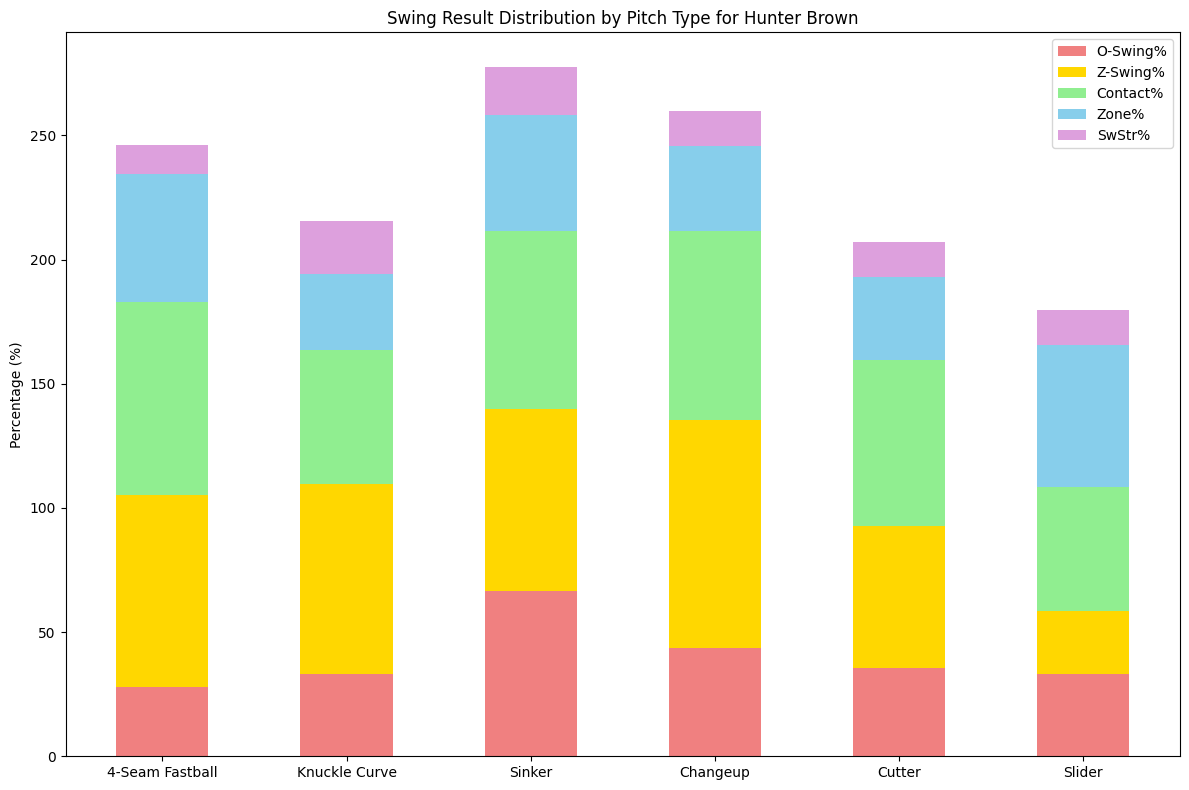

In [5]:
def plot_swing_result_distribution(agg_df: pd.DataFrame, pitcher_name: str):
    """
    Plots a stacked bar chart showing the distribution of Swing Results 
    (O-Swing%, Z-Swing%, Contact%, Zone%, SwStr%) for each pitch type.
    """
    if agg_df.empty:
        print("No data available to plot Swing Result Distribution.")
        return

    # Set up the bar chart
    pitch_types = agg_df['Pitch']
    x = np.arange(len(pitch_types))
    width = 0.5

    # Extract metrics for plotting
    o_swing = agg_df['O-Swing%']
    z_swing = agg_df['Z-Swing%']
    contact = agg_df['Contact%']
    zone = agg_df['Zone%']
    sw_str = agg_df['SwStr%']

    # Create stacked bars
    fig, ax = plt.subplots(figsize=(12, 8))

    ax.bar(x, o_swing, width, label='O-Swing%', color='lightcoral')
    ax.bar(x, z_swing, width, bottom=o_swing, label='Z-Swing%', color='gold')
    ax.bar(x, contact, width, bottom=o_swing + z_swing, label='Contact%', color='lightgreen')
    ax.bar(x, zone, width, bottom=o_swing + z_swing + contact, label='Zone%', color='skyblue')
    ax.bar(x, sw_str, width, bottom=o_swing + z_swing + contact + zone, label='SwStr%', color='plum')

    # Labels and Title
    ax.set_ylabel('Percentage (%)')
    ax.set_title(f'Swing Result Distribution by Pitch Type for {pitcher_name}')
    ax.set_xticks(x)
    ax.set_xticklabels(pitch_types)
    ax.legend()

    plt.tight_layout()
    plt.show()

plot_swing_result_distribution(final_metrics_df, PITCHER_NAME)